In [18]:
import json

def count_chars(filename):
    with open(filename) as f:
        nb = json.load(f)
    
    counts = {'code': 0, 'markdown': 0, 'raw': 0, 'other': 0}
    
    for cell in nb['cells']:
        cell_type = cell['cell_type']
        chars = sum(len(line) for line in cell['source'])
        if cell_type in counts:
            counts[cell_type] += chars
        else:
            counts['other'] += chars
    
    total = sum(counts.values())
    
    for cell_type in ['code', 'markdown', 'raw', 'other']:
        print(f"{cell_type},{counts[cell_type]}")
    
    print(f"total,{total}")
    
    if total > 75000:
        print("Too many characters in assignment submission (> 75,000)")
    else:
        print("Number of characters ok ( < 75,000)")

count_chars('Task-2.ipynb')

code,5602
markdown,12342
raw,0
other,0
total,17944
Number of characters ok ( < 75,000)


## Table of Contents
1. [Introduction](#10-introduction)
2. [Python Libraries and their sources](#11-python-libraries-and-their-sources)
3. [Import Required Libraries](#12-import-required-libraries)
4. [Part A: Multiple Linear Regression (Dataset 2)](#13-part-a-multiple-linear-regression-dataset-2)
   1. [Algorithm Deep Dive: The Hyperplane and beyond](#131-algorithm-deep-dive-the-hyperplane-and-beyond)
   2. [Data Loading & Visual Review](#132-data-loading--visual-review)  
   3. [Building and Evaluating the MLR Model](#133-building-and-evaluating-the-mlr-model)
5. [Part B: Polynomial Regression (Dataset 1)](#14-part-b-polynomial-regression-dataset-1)
   1. [Algorithm Deep Dive: Feature Engineering](#141-algorithm-deep-dive-feature-engineering)
   2. [Visualizing the Linear Baseline Failure](#142-visualizing-the-linear-baseline-failure)
   3. [Building and Evaluating the Polynomial Model](#143-building-and-evaluating-the-polynomial-model)
   4. [Model Comparison - MLR vs Polynomial Regression](#144-model-comparison-mlr-vs-polynomial-regression)
   5. [Computational Complexity](#145-computational-complexity)
6. [The Danger Zone - Runges Phenomenon](#15-the-danger-zone-runges-phenomenon)
7. [Practical Guidelines](#16-practical-guidelines)
8. [Final Thoughts](#17-final-thoughts)
9.  [Summary Table Key Concepts](#18-summary-table-key-concepts)
10. [Model Performance Summary](#19-model-performance-summary)
11. [References](#20-references)

## 1.0 Introduction
In the real world, target variables are rarely driven by a single feature, nor do they strictly adhere to straight lines.

In this tutorial, we will review `multivariate and polynomial` expansions of the linear model.

From Task-1, we found that the `Polynomial Regression was the best fit model for Dataset-1` and `Multiple Linear Regression was the best fit model for Dataset-2`.

**The Core Academic Insight:**
As we will explore in this tutorial, **Multiple Linear Regression** and **Polynomial Regression** are mathematically identical under the hood. They both rely on the Ordinary Least Squares (OLS) algorithm. The difference lies entirely in how we structure the input data *before* feeding it to the algorithm. Let's dive in.

### 1.1 Python libraries and their sources:

As part of the assignment, I have used the below listed Python libraries:

1. pandas - Python Data Analytics Library
   
    - https://pandas.pydata.org/

2. numpy - Scientific computing with Python

    - https://numpy.org/

3. missingno - Visualising missing data in dataframes

    - https://github.com/ResidentMario/missingno

4. scikit-learn - Machine Learning Library for Python

    - https://scikit-learn.org/stable/

5. matplotlib - Visualisation with Python

    - https://matplotlib.org/

6. seaborn - Statistical data visualisation

    - https://seaborn.pydata.org/

## 1.2 Import Required Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Visualization
from matplotlib.pyplot import figure
from pandas.plotting import scatter_matrix

# ML Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score

# Set display precision for pandas tables (Standard pedagogical practice)
pd.set_option('display.precision', 2)
sns.set_theme(style="whitegrid")

### 1.3.1 Algorithm Deep Dive: The Hyperplane and Beyond

**The Mathematical Formulation:**

Multiple Linear Regression extends the simple linear model to p dimensions:

$$y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_p x_{ip} + \epsilon_i$$

In matrix notation, this compactly becomes:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

Where:
- $\mathbf{y}$ is the $n \times 1$ vector of target values
- $\mathbf{X}$ is the $n \times (p+1)$ design matrix (with a column of ones for the intercept)
- $\boldsymbol{\beta}$ is the $(p+1) \times 1$ vector of coefficients
- $\boldsymbol{\epsilon}$ is the $n \times 1$ vector of errors

**How OLS Finds the Optimal Hyperplane:**

The Ordinary Least Squares (OLS) estimator minimizes the sum of squared residuals:

$$\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}} \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \arg\min_{\boldsymbol{\beta}} (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

The closed-form solution, derived by taking partial derivatives and setting them to zero, is:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

This elegant formula reveals that the coefficients are a linear transformation of the target values, and their existence requires $\mathbf{X}^T\mathbf{X}$ to be invertible (no perfect multicollinearity).

**Geometric Interpretation:**

The hyperplane represents the best linear approximation of the conditional expectation $E[y|\mathbf{x}]$ in the least squares sense. In our 3D visualization, this appears as a flat "sheet" cutting through the point cloud, minimizing the vertical distances to all data points.

**Assumptions Underlying MLR:**

For OLS estimates to be BLUE (Best Linear Unbiased Estimators), we rely on the Gauss-Markov assumptions:
1. **Linearity**: The relationship between predictors and response is linear
2. **No perfect multicollinearity**: $\mathbf{X}$ has full column rank
3. **Zero conditional mean**: $E[\epsilon|\mathbf{X}] = 0$ (exogeneity)
4. **Homoscedasticity**: $Var(\epsilon|\mathbf{X}) = \sigma^2$ (constant variance)
5. **No autocorrelation**: $Cov(\epsilon_i, \epsilon_j|\mathbf{X}) = 0$ for $i \neq j$

While normality of errors is not required for unbiasedness, it is needed for valid hypothesis testing with small samples.

Dataset 2 Shape: (600, 3)


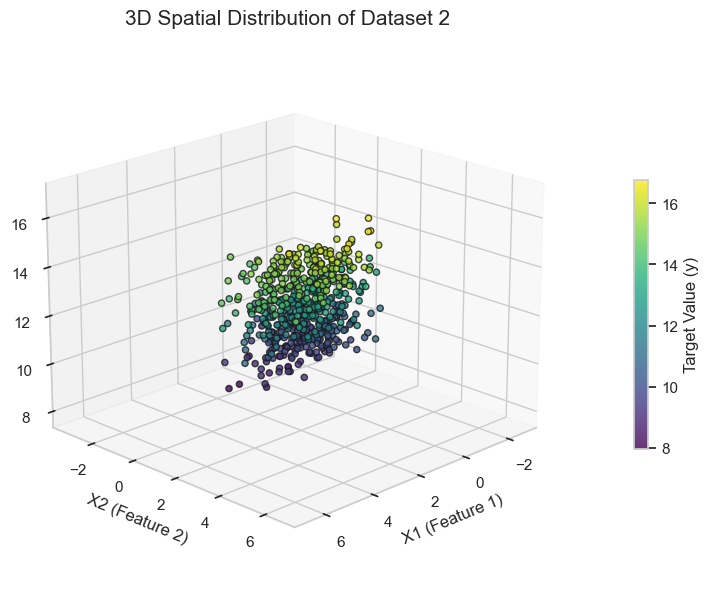

In [11]:
# Load Dataset 2
df2 = pd.read_csv('CML_2026-01-26#5-dataset_2.csv')

print(f"Dataset 2 Shape: {df2.shape}")

# 3D Scatter Plot for Spatial Review
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Color map tied to 'y' to aid depth perception
scatter = ax.scatter(df2['X1'], df2['X2'], df2['y'], c=df2['y'], cmap='viridis', alpha=0.8, edgecolor='k')

ax.set_title("3D Spatial Distribution of Dataset 2", fontsize=15, pad=15)
ax.set_xlabel("X1 (Feature 1)")
ax.set_ylabel("X2 (Feature 2)")
ax.set_zlabel("y (Target)")
plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1, label='Target Value (y)')
ax.view_init(elev=20, azim=45)
plt.show()


> **_Note:_** The 3D plot confirms the data is dispersed across a flat, tilted plane. We can now safely partition the data into training and testing sets and apply our MLR algorithm.

### 1.3.3 Building and Evaluating the MLR Model
Notice that in `scikit-learn`, we simply pass a dataframe with multiple columns into the standard `LinearRegression()` object. The algorithm automatically detects the multiple dimensions and calculates the hyperplane.

MLR R^2 Score (Goodness of Fit): 0.8063
MLR Mean Squared Error:          0.95


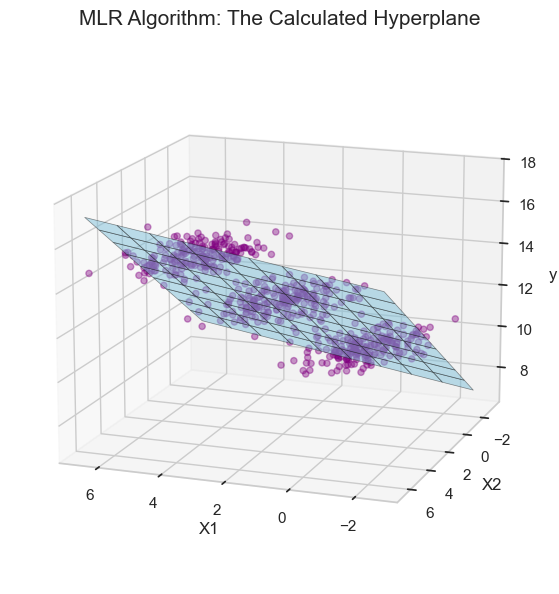

In [12]:
# Train/Test Split
X2_features = df2[['X1', 'X2']]
y2_target = df2['y']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_features, y2_target, test_size=0.2, random_state=42)

# Build and Train the MLR Model
mlr_model = LinearRegression()
mlr_model.fit(X2_train, y2_train)

# Evaluate
y2_pred = mlr_model.predict(X2_test)
print(f"MLR R^2 Score (Goodness of Fit): {r2_score(y2_test, y2_pred):.4f}")
print(f"MLR Mean Squared Error:          {mean_squared_error(y2_test, y2_pred):.2f}")

# Visualize the Calculated Hyperplane
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df2['X1'], df2['X2'], df2['y'], color='purple', alpha=0.4, label='Raw Data')

# Generate a dense mathematical grid to represent the calculated plane
x1_grid, x2_grid = np.meshgrid(np.linspace(df2['X1'].min(), df2['X1'].max(), 10),
                               np.linspace(df2['X2'].min(), df2['X2'].max(), 10))
y_plane = mlr_model.predict(pd.DataFrame({'X1': x1_grid.ravel(), 'X2': x2_grid.ravel()}))
y_plane = y_plane.reshape(x1_grid.shape)

# Overlay the plane
ax.plot_surface(x1_grid, x2_grid, y_plane, color='skyblue', alpha=0.5, edgecolor='k', linewidth=0.5)

ax.set_title("MLR Algorithm: The Calculated Hyperplane", fontsize=15, pad=15)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("y")
ax.view_init(elev=15, azim=110)
plt.show()

**Residual Analysis**

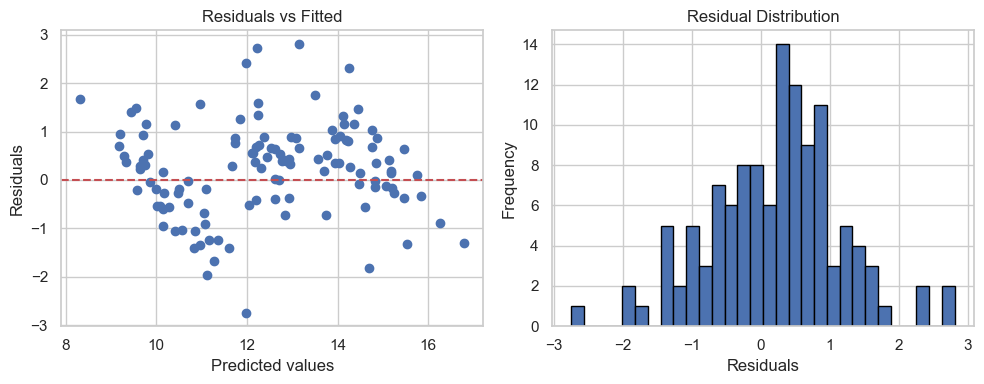

In [29]:
residuals_mlr = y2_test - y2_pred
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y2_pred, residuals_mlr)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

plt.subplot(1, 2, 2)
plt.hist(residuals_mlr, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

## 1.4 Part B: Polynomial Regression (Dataset 1)

### 1.4.1 Algorithm Deep Dive: Feature Engineering

**The Core Insight:**

Polynomial Regression is fundamentally a **linear model in the transformed feature space**. Consider a degree-d polynomial in one variable:

$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \dots + \beta_d x^d + \epsilon$$

If we define new features:
$$z_1 = x,\quad z_2 = x^2,\quad z_3 = x^3,\quad \dots,\quad z_d = x^d$$

Then the model becomes:

$$y = \beta_0 + \beta_1 z_1 + \beta_2 z_2 + \beta_3 z_3 + \dots + \beta_d z_d + \epsilon$$

This is **exactly the same form as multiple linear regression!** The "polynomial" nature emerges only when we plot $y$ against the original $x$ axis.

**The Bias-Variance Tradeoff:**

The degree $d$ acts as a complexity parameter:
- **Low degree (e.g., d=1)**: High bias, low variance — underfitting
- **Optimal degree**: Balances bias and variance — good generalization
- **High degree**: Low bias, high variance — overfitting (Runge's phenomenon)

**Mathematical Underpinnings:**

We can view polynomial regression as a special case of basis function expansion:

$$y = \sum_{j=0}^d \beta_j \phi_j(x) + \epsilon$$

where $\phi_j(x) = x^j$ are the basis functions. This framework extends to other bases (splines, Fourier, wavelets) for more sophisticated nonlinear modeling.

**Why It Works:**

The Taylor series expansion tells us that any smooth function can be approximated locally by a polynomial of sufficiently high degree. By including polynomial terms, we allow the model to capture curvature, inflection points, and other nonlinear patterns that a straight line cannot represent.

Baseline Linear R^2 Score: 0.4118 (Very Poor)


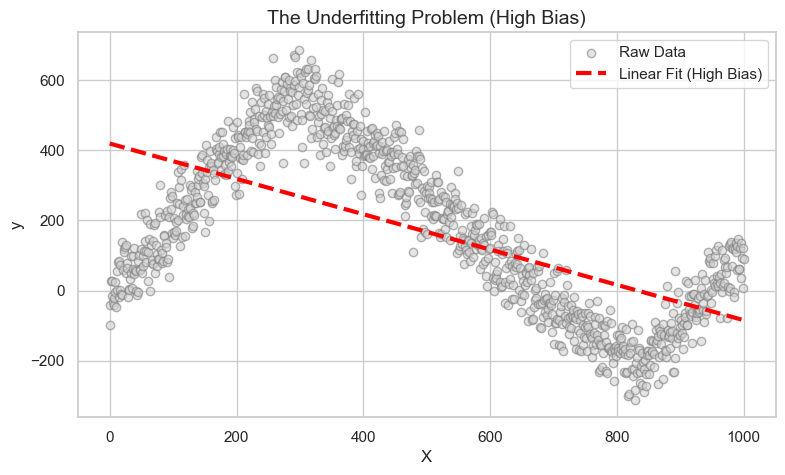

In [13]:
# Load Dataset 1
df1 = pd.read_csv('CML_2026-01-26#4-dataset_1.csv')
X1 = df1[['X']]
y1 = df1['y']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Train Baseline Linear Model
baseline_lr = LinearRegression()
baseline_lr.fit(X1_train.values, y1_train.values)

# Evaluate Failure
y1_pred_base = baseline_lr.predict(X1_test.values)
print(f"Baseline Linear R^2 Score: {r2_score(y1_test, y1_pred_base):.4f} (Very Poor)")

# Visualize Underfitting
X1_smooth = np.linspace(X1.min(), X1.max(), 500).reshape(-1, 1)

plt.figure(figsize=(9, 5))
plt.scatter(X1, y1, color='lightgray', label='Raw Data', alpha=0.6, edgecolor='gray')
plt.plot(X1_smooth, baseline_lr.predict(X1_smooth), color='red', linewidth=3, linestyle='--', label='Linear Fit (High Bias)')
plt.title("The Underfitting Problem (High Bias)", fontsize=14)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### 1.4.3 Building and Evaluating the Polynomial Model
We will use `PolynomialFeatures(degree=3)` to mathematically engineer $X^2$ and $X^3$. By chaining this directly into `LinearRegression()` using a pipeline, we allow the algorithm to "bend."

Polynomial (Degree 3) R^2 Score: 0.9249 (Excellent Fit)
Polynomial (Degree 3) MSE:       4500.11


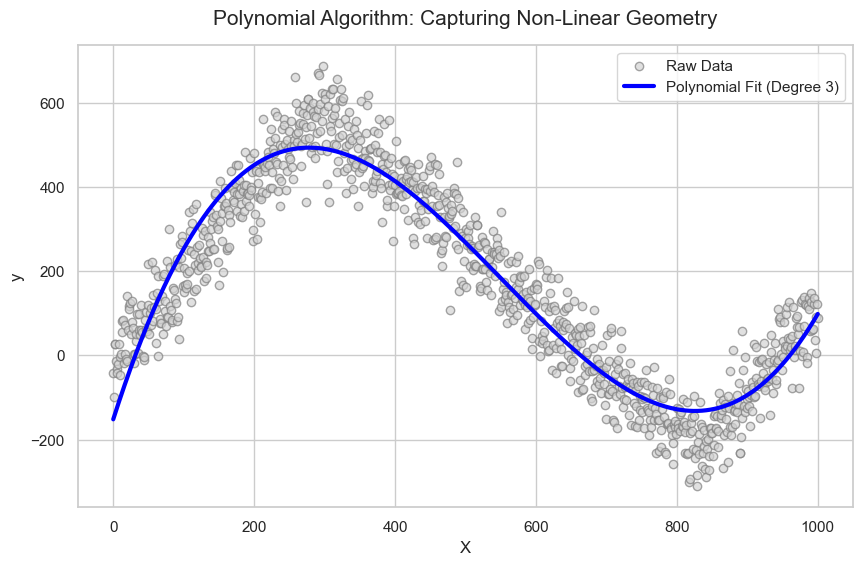

In [14]:
# 1. Build the Pipeline (Degree 3)
poly_pipeline = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())

# 2. Train the Pipeline
poly_pipeline.fit(X1_train.values, y1_train.values)

# 3. Evaluate Success
y1_pred_poly = poly_pipeline.predict(X1_test.values)
print(f"Polynomial (Degree 3) R^2 Score: {r2_score(y1_test, y1_pred_poly):.4f} (Excellent Fit)")
print(f"Polynomial (Degree 3) MSE:       {mean_squared_error(y1_test, y1_pred_poly):.2f}")

# 4. Visualize the Curve
plt.figure(figsize=(10, 6))
plt.scatter(X1, y1, color='lightgray', label='Raw Data', alpha=0.7, edgecolor='gray')

# Plot the smooth polynomial prediction
plt.plot(X1_smooth, poly_pipeline.predict(X1_smooth), color='blue', linewidth=3, label='Polynomial Fit (Degree 3)')

plt.title("Polynomial Algorithm: Capturing Non-Linear Geometry", fontsize=15, pad=15)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

**Residual Analysis**

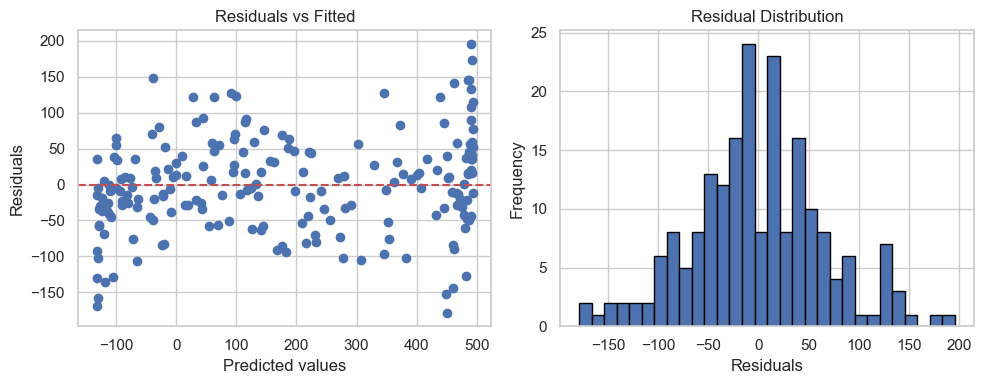

In [28]:
residuals_poly = y1_test - y1_pred_poly
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y1_pred_poly, residuals_poly)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

plt.subplot(1, 2, 2)
plt.hist(residuals_poly, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

### 1.4.4 Model Comparison: MLR vs. Polynomial Regression

**Structural Differences:**

| Aspect | Multiple Linear Regression | Polynomial Regression |
|--------|---------------------------|----------------------|
| **Input features** | Multiple independent variables | Powers of a single variable |
| **Model flexibility** | Fixed linear form | Adjustable via degree parameter |
| **Interpretability** | Coefficients have direct meaning | Coefficients less intuitive |
| **Risk** | Underfitting (bias) | Overfitting (variance) |

**When to Use Each:**

- **MLR**: Use when domain knowledge suggests linear relationships or when you have multiple distinct predictors that contribute independently to the target.

- **Polynomial Regression**: Use when:
  1. You have only one predictor variable
  2. Scatter plots reveal clear curvature
  3. Residual analysis shows systematic patterns in a linear model

**Practical Considerations:**

**Scaling**: Polynomial features can have vastly different scales (e.g., $x$ vs $x^3$). Standardization is crucial for numerical stability:

$$z = \frac{x - \mu_x}{\sigma_x}$$

**Interaction Terms**: For multiple predictors, we can extend polynomial regression to include interaction terms:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1^2 + \beta_4 x_2^2 + \beta_5 x_1 x_2 + \epsilon$$

This allows capturing synergy between variables.

**Choosing the Degree:**

Cross-validation is the standard approach:

### 1.4.5 Computational Complexity:

**Computational Note:** For polynomial regression with degree $d$ and $p$ features, the number of terms grows as $\binom{p+d}{d}$. With $p=1$, this is $d+1$ terms. With $p=10$ and $d=3$, this becomes $\binom{13}{3} = 286$ terms, making it computationally intensive.

## 1.5 The Danger Zone: Runge's Phenomenon
If a 3rd-degree polynomial provides an excellent fit, novice data scientists often assume a 15th-degree polynomial will be flawless. **This is mathematically catastrophic.**

When we push the degree too high, the model gains excessive parametric flexibility. Rather than drawing a smooth macroscopic curve *through* the center of mass, the line will violently oscillate to touch every single random noise artifact in the training set. This is known as **Runge's Phenomenon**, or **High Variance (Overfitting)**. The model memorizes the noise, destroying its ability to predict new test data.

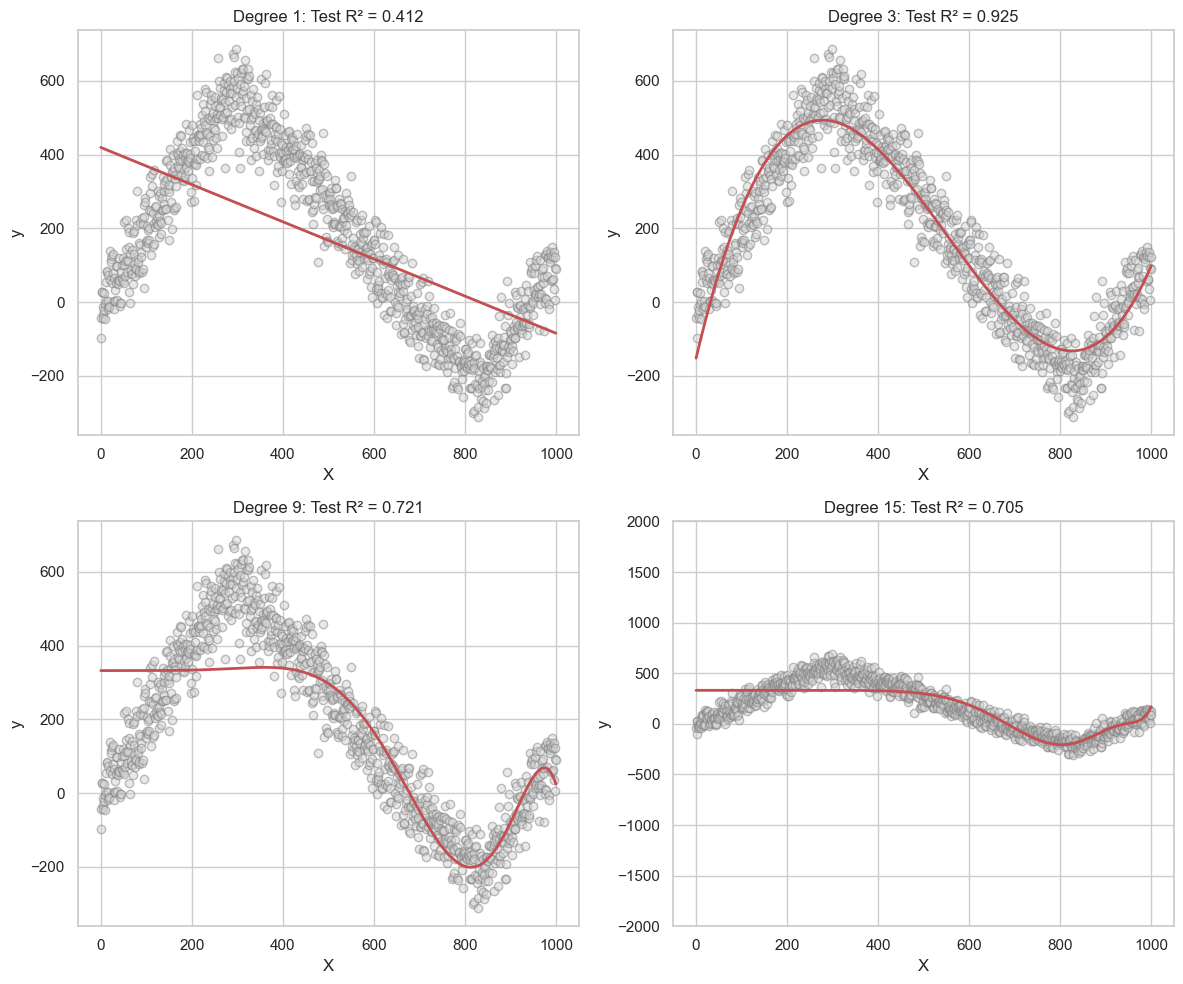

In [27]:
# Demonstration of Runge's Phenomenon (Overfitting)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
degrees = [1, 3, 9, 15]

for i, d in enumerate(degrees):
    poly = make_pipeline(PolynomialFeatures(d), LinearRegression())
    poly.fit(X1_train.values, y1_train.values)
    
    ax = axes[i//2, i%2]
    ax.scatter(X1, y1, alpha=0.5, color='lightgray', edgecolor='gray')
    ax.plot(X1_smooth, poly.predict(X1_smooth), 'r-', linewidth=2)
    ax.set_title(f'Degree {d}: Test R² = {poly.score(X1_test.values, y1_test.values):.3f}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    
    # Zoom in on high-degree plots to show oscillations
    if d > 9:
        ax.set_ylim(-2000, 2000)

plt.tight_layout()
plt.show()

## 1.6 Practical Guidelines:

- Never use polynomial degree > 5-6 without regularization
- Prefer splines over high-degree polynomials
- Always visualize your fits, especially at the boundaries

## 1.7 Final Thoughts
As demonstrated throughout this workbook:
* The core OLS (Ordinary Least Squares) algorithm is incredibly versatile. 
* By structuring our raw data differently—either by including multiple distinct real-world variables (Dataset 2) or by mathematically squaring a single variable (Dataset 1)—we can map multi-dimensional planes and complex curves with the exact same mathematical engine.
* However, with great parametric flexibility comes the great responsibility of preventing overfitting!

## 1.8 Summary Table: Key Concepts

| Concept | Description | Mathematical Form | Key Considerations |
|---------|-------------|-------------------|-------------------|
| **OLS** | Minimizes squared errors | $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ | Requires invertible $\mathbf{X}^T\mathbf{X}$ |
| **MLR** | Models linear relationships with multiple predictors | $y = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p + \epsilon$ | Check multicollinearity, residuals |
| **Polynomial Regression** | Adds powers of predictors to capture curvature | $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d + \epsilon$ | Scale features, avoid high d |
| **Overfitting** | Model fits noise, fails to generalize | High training $R^2$, low test $R^2$ | Use regularization, cross-validation |
| **Underfitting** | Model too simple to capture patterns | Low training $R^2$, low test $R^2$ | Increase model complexity |



## 1.9 Model Performance Summary

| Model | R² Score | MSE | Key Insight |
|-------|----------|-----|-------------|
| Baseline Linear (Dataset 1) | 0.4118 | 36741.52 | Underfitting (high bias) |
| Polynomial (Degree 3) | 0.9249 | 4500.11 | Captures curvature well |
| MLR (Dataset 2) | 0.8063 | 0.95 | Good fit for planar data |

## 2.0 References

1. **Hastie, T., Tibshirani, R., & Friedman, J. (2009).** *The Elements of Statistical Learning*. Springer. (Chapters 3-5)

2. **James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021).** *An Introduction to Statistical Learning*. Springer. (Chapters 3, 7)

3. **Bishop, C. M. (2006).** *Pattern Recognition and Machine Learning*. Springer. (Chapters 1, 3)